In [ ]:
!python --version

# ***Packages***

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [ ]:
import locale
import inspect
import os
import sys
locale.getpreferredencoding = lambda: "UTF-8"

sys.path.append('MODIFIED_PYTHON_MODULES/modified_ot')
import ot

module_path = inspect.getfile(ot)
# Get the directory containing the module
module_directory = os.path.dirname(module_path)

print(f"Module directory: {module_directory}")

sys.path.append('MODIFIED_PYTHON_MODULES/modified_paste')
import paste as pst

module_path = inspect.getfile(pst)
module_directory = os.path.dirname(module_path)

print(f"Module directory: {module_directory}")


Check for GPU support

In [ ]:
!nvidia-smi

# ***Data***

In [6]:
def load_data(data_dir, data1, data2):    

    sliceA = sc.read_h5ad(data_dir + data1 + ".h5ad")
    sliceB = sc.read_h5ad(data_dir + data2 + ".h5ad")

    xI = np.array(sliceA.obsm['spatial'] [:, 0])
    yI = np.array(sliceA.obsm['spatial'] [:, 1])

    xJ = np.array(sliceB.obsm['spatial'] [:, 0])
    yJ = np.array(sliceB.obsm['spatial'] [:, 1])

    plt.scatter(xI,yI,s=1,alpha=1, label='source')
    plt.axis("off")
    plt.legend()
    plt.show()

    plt.scatter(xJ,yJ,s=1,alpha=1, c='#ff7f0e',  label='target')
    plt.axis("off")
    plt.legend()
    plt.show()

    return sliceA, sliceB


In [7]:
def visualize_alignment(sliceA, sliceB, pi12):
    slices, pis = [sliceA, sliceB], [pi12]
    new_slices = pst.stack_slices_pairwise(slices, pis)

    slice_colors = ['#e41a1c','#377eb8']

    xI_new = new_slices[0].obsm['spatial'][:, 0]
    yI_new = new_slices[0].obsm['spatial'][:, 1]

    xJ_new = new_slices[1].obsm['spatial'][:, 0]
    yJ_new = new_slices[1].obsm['spatial'][:, 1]

    print("====================\nAligned slices")

    plt.scatter(xI_new,yI_new,s=1,alpha=0.5, label='source', c=slice_colors[0])
    plt.scatter(xJ_new,yJ_new,s=1,alpha=0.5, label = 'target', c=slice_colors[1])
    plt.axis("off")
    plt.legend()
    plt.show()

    return new_slices

    

# ***Apply Method***

In [8]:
def cell_type_matching_metric_stalign(threshold, slice1, slice2):
    from sklearn.metrics.pairwise import euclidean_distances

    matching_cell_types = 0

    # Extract coordinates from both slices
    source_coords = slice1.obsm['spatial']
    target_coords = slice2.obsm['spatial']

    distances = euclidean_distances(source_coords, target_coords)

    processed_target_cells = set()

    # Iterate through each cell in the source slice
    for source_cell_index in range(distances.shape[0]):
        # find the indices of target cells within the threshold
        target_indices = np.where(distances[source_cell_index] <= threshold)[0]
        if len(target_indices) == 0:
            # print("nothing found")
            continue

        # if any one of the target cells are of the same cell_type of the current source cell incrase count
        for target_cell_index in target_indices:
            if target_cell_index not in processed_target_cells and slice1.obs['cell_type_annot'][source_cell_index] == slice2.obs['cell_type_annot'][target_cell_index]:
                matching_cell_types += 1
                processed_target_cells.add(target_cell_index)
                break
    
    percentage = matching_cell_types / slice1.n_obs * 100

    return matching_cell_types, percentage


In [9]:
def run_stalign(sliceA, sliceB, data1, data2, dataPath, overwrite=False):
    from STalign import STalign
    import torch
    from sklearn.metrics.pairwise import euclidean_distances

    filePath = f'{dataPath}/{data1}_{data2}'

    def get_js_dist_neighborhood(slice1, slice2, radius):
        neighborhood_dist_slice1 = pst.helper.get_neighborhood_distribution(slice1, radius) + 0.01
        neighborhood_dist_slice2 = pst.helper.get_neighborhood_distribution(slice2, radius) + 0.01

        js_dist_neighborhood = pst.helper.jensenshannon_divergence_backend(neighborhood_dist_slice1, neighborhood_dist_slice2)
        js_dist_neighborhood = np.asarray(js_dist_neighborhood)

        return js_dist_neighborhood
    
    def get_cosine_dist_gene_expr(slice1, slice2):
        cosine_dist_gene_expr = pst.helper.cosine_dist_calculator(slice1, slice2, data1, data2, filePath)
        return cosine_dist_gene_expr
    
    def cellular_neighborhood_gene_expr_metric(radius, slice1, slice2):

        pi_mat = np.zeros((slice1.shape[0], slice2.shape[0]))

        # Extract coordinates from both slices
        source_coords = slice1.obsm['spatial']
        target_coords = slice2.obsm['spatial']

        # Calculate pairwise Euclidean distances using cdist_sparse
        distances = euclidean_distances(source_coords, target_coords)

        # Process the priority queue to ensure only one match per source cell
        processed_source_cells = set()


        # Iterate through each cell in the source slice
        for source_cell_index in range(distances.shape[0]):

            # Find the index of the closest target cell within the threshold
            closest_target_index = distances[source_cell_index].argmin()  # Find the index of the minimum distance

            # allowing one to many mapping
            if source_cell_index in processed_source_cells:
                continue

            # Check if the closest distance is within the threshold
            # if closest_distance <= threshold:
            processed_source_cells.add(source_cell_index)
            # processed_target_cells.add(closest_target_index)
            pi_mat[source_cell_index, closest_target_index] = 1/slice1.n_obs

        js_dist_neighborhood = get_js_dist_neighborhood(slice1, slice2, radius)
        obj_neighbor = np.sum(js_dist_neighborhood*pi_mat)

        cosine_dist_gene_expr = get_cosine_dist_gene_expr(slice1, slice2)
        obj_gene_cos = np.sum(cosine_dist_gene_expr * pi_mat)

        return pi_mat, obj_neighbor, obj_gene_cos

    # Calculate the initial objective values
    a = np.ones((sliceA.shape[0],))/sliceA.shape[0]
    b = np.ones((sliceB.shape[0],))/sliceB.shape[0]
    G = np.ones((a.shape[0], b.shape[0])) / (a.shape[0] * b.shape[0])


    radius = 100

    cosine_dist_gene_expr = get_cosine_dist_gene_expr(sliceA, sliceB)
    initial_obj_gene_cos = np.sum(cosine_dist_gene_expr*G)

    js_dist_neighborhood = get_js_dist_neighborhood(sliceA, sliceB, radius)
    np.save(f'{filePath}/js_dist_neighborhood.npy', js_dist_neighborhood)
    initial_obj_neighbor = np.sum(js_dist_neighborhood*G)


    # Run STalign pipeline
    # taken from the tutorial (https://jef.works/STalign/notebooks/merfish-merfish-alignment.html)
    
    xI = np.array(sliceA.obsm['spatial'] [:, 0])
    yI = np.array(sliceA.obsm['spatial'] [:, 1])

    xJ = np.array(sliceB.obsm['spatial'] [:, 0])
    yJ = np.array(sliceB.obsm['spatial'] [:, 1])


    if os.path.exists(f'{filePath}/tpointsI_{data1}.npy') and not overwrite:
        tpointsI = np.load(f'{filePath}/tpointsI_{data1}.npy')
    
    else:
    
        # initial affine transformation
        theta_deg = 0
        theta0 = (np.pi/180)*-theta_deg

        #rotation matrix
        #rotates about the origin
        L = np.array([[np.cos(theta0),-np.sin(theta0)],
                    [np.sin(theta0),np.cos(theta0)]])

        source_L = np.matmul(L , np.array([xI, yI]))
        xI_L = source_L[0]
        yI_L = source_L[1]

        #translation matrix
        #effectively makes the rotation about the centroid of I (i.e the means of xI and yI])
        #and also moves the centroid of I to the centroid of J
        T = np.array([ np.mean(xI)- np.cos(theta0)*np.mean(xI) +np.sin(theta0)*np.mean(yI) - (np.mean(xI)-np.mean(xJ)),
                    np.mean(yI)- np.sin(theta0)*np.mean(xI) -np.cos(theta0)*np.mean(yI) - (np.mean(yI)-np.mean(yJ))])

        xI_L_T = xI_L + T[0]
        yI_L_T = yI_L + T[1]


        fig,ax = plt.subplots()
        ax.scatter(xI_L_T,yI_L_T,s=1,alpha=0.1, label='source with initial affine transformation')
        ax.scatter(xJ,yJ,s=1,alpha=0.1, label = 'target')
        ax.legend(markerscale = 10)

        # rasterize at 30um resolution (assuming positions are in um units) and plot
        XI,YI,I,fig = STalign.rasterize(xI_L_T,yI_L_T,dx=30,blur=1.5)

        # plot
        ax = fig.axes[0]
        ax.invert_yaxis()

        # rasterize and plot
        XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=30, blur=1.5)
        ax = fig.axes[0]
        ax.invert_yaxis()

        # get extent of images
        extentI = STalign.extent_from_x((YI,XI))
        extentJ = STalign.extent_from_x((YJ,XJ))

        # plot rasterized images
        fig,ax = plt.subplots(1,2)
        ax[0].imshow(I[0], extent=extentI)
        ax[1].imshow(J[0], extent=extentJ)
        ax[0].invert_yaxis()
        ax[1].invert_yaxis()

        # run LDDMM
        # specify device (default device for STalign.LDDMM is cpu)
        if torch.cuda.is_available():
            device = 'cuda:0'
        else:
            device = 'cpu'

        # keep all other parameters default
        params = {
                    'niter': 5000,
                    'device':device,
                    'epV': 50
                }

        out = STalign.LDDMM([YI,XI],I,[YJ,XJ],J,**params)

        # get necessary output variables
        A = out['A']
        v = out['v']
        xv = out['xv']

        # set device for building tensors
        if torch.cuda.is_available():
            torch.set_default_device('cuda:0')
        else:
            torch.set_default_device('cpu')

        # apply transform
        phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
        phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])

        #switch tensor from cuda to cpu for plotting with numpy
        if phii.is_cuda:
            phii = phii.cpu()
        if phiI.is_cuda:
            phiI = phiI.cpu()

        # plot with grids
        fig,ax = plt.subplots()
        levels = np.arange(-100000,100000,1000)
        ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
        ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
        ax.set_aspect('equal')
        ax.set_title('source to target')
        ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
        ax.invert_yaxis()

        #switch tensor from cuda to cpu for plotting with numpy
        if phii.is_cuda:
            phii = phii.cpu()
        if phiI.is_cuda:
            phiI = phiI.cpu()


        # transform is invertible
        phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
        phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])

        #switch tensor from cuda to cpu for plotting with numpy
        if phi.is_cuda:
            phi = phi.cpu()
        if phiiJ.is_cuda:
            phiiJ = phiiJ.cpu()

        # plot with grids
        fig,ax = plt.subplots()
        levels = np.arange(-100000,100000,1000)
        ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
        ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
        ax.set_aspect('equal')
        ax.set_title('target to source')
        ax.imshow(phiiJ.permute(1,2,0)/torch.max(phiiJ),extent=extentI)
        ax.invert_yaxis()

        #switch tensor from cuda to cpu for plotting with numpy
        if phi.is_cuda:
            phi = phi.cpu()
        if phiiJ.is_cuda:
            phiiJ = phiiJ.cpu()

        # apply transform to original points
        tpointsI= STalign.transform_points_source_to_target(xv,v,A, np.stack([yI_L_T, xI_L_T], 1))

        #switch tensor from cuda to cpu for plotting with numpy
        if tpointsI.is_cuda:
            tpointsI = tpointsI.cpu()

        if not os.path.exists(filePath):
            os.makedirs(filePath)
        np.save(f'{filePath}/tpointsI_{data1}.npy', tpointsI)
    
    # switch from row column coordinates (y,x) to (x,y)
    xI_LDDMM = tpointsI[:,1]
    yI_LDDMM = tpointsI[:,0]

    # re-center the transformed points
    centroid_I = np.mean(np.vstack((xI_LDDMM, yI_LDDMM)), axis=1)
    centroid_J = np.mean(np.vstack((xJ, yJ)), axis=1)
    translation_vector = centroid_J - centroid_I
    xI_LDDMM = xI_LDDMM + translation_vector[0]
    yI_LDDMM = yI_LDDMM + translation_vector[1]

    # visualize the alignment
    plt.clf()
    plt.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.4, label = 'source STaligned')
    plt.scatter(xJ,yJ,s=1,alpha=0.2, label='target')
    plt.legend(markerscale = 10, loc = 'lower left')
    plt.axis("off")
    plt.show()
    plt.clf()

    sliceA_LDDMM = sliceA.copy()
    # update the spatial coordinates
    sliceA_LDDMM.obsm['spatial'][:, 0] = xI_LDDMM
    sliceA_LDDMM.obsm['spatial'][:, 1] = yI_LDDMM

    new_slices = [sliceA_LDDMM, sliceB]

    pi_mat, final_obj_neighbor, final_obj_gene_cos = cellular_neighborhood_gene_expr_metric(radius, sliceA_LDDMM, sliceB)

    return pi_mat, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices


In [10]:
def run_method(sliceA, sliceB, data1, data2, method_name):

    if method_name.lower() == 'promt':

        pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos = pst.pairwise_align_MERFISH(sliceA = sliceA, sliceB = sliceB, backend = ot.backend.TorchBackend(),
                                            use_gpu = True, return_obj = True,
                                            sliceA_name=data1, sliceB_name=data2, alpha=0.1, beta= 0.8, gamma=0.8, radius=100,
                                            numItermax = 20000, overwrite = True, neighborhood_dissimilarity = 'jsd',
                                            filePath = f'{os.getcwd()}/local_data/{method_name}')
        
        np.save(f'{os.getcwd()}/local_data/{method_name}/js_dist_neighbor_init_{data1}_{data2}.npy', initial_obj_neighbor)
        new_slices = visualize_alignment(sliceA, sliceB, pi12)
        return pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices
    
    elif method_name.lower() == 'paste':

        pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos = pst.pairwise_align(sliceA = sliceA, sliceB = sliceB, backend = ot.backend.TorchBackend(),
                                    use_gpu = True, return_obj = True,
                                    sliceA_name=data1, sliceB_name=data2, alpha=0.1, beta= 0.8, gamma=0.8, radius=100,
                                    numItermax = 20000, overwrite = True,
                                    filePath = f'{os.getcwd()}/local_data/{method_name}')

        new_slices = visualize_alignment(sliceA, sliceB, pi12)
        return pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices

    elif method_name.lower() == 'stalign':
        
        pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices = run_stalign(sliceA, sliceB, data1, data2, f'{os.getcwd()}/local_data/{method_name}', overwrite=False)

        return pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices
    
    else:
        print("Method not found")
        return None


In [11]:
def save_pi_matrix(pi12, data1, data2, method_name):
    filePath = f'{os.getcwd()}/local_data/{method_name}'
    np.save(f"{filePath}/pi_matrix_{data1}_{data2}.npy", pi12)

In [12]:
def cell_type_matching_metric(sliceA, sliceB, pi_mat):

    matching_cell_types = 0

    max_indices = np.argmax(pi_mat, axis=1)
    for i, max_index in enumerate(max_indices):

        if sliceA.obs.iloc[i]['cell_type_annot'] == sliceB.obs.iloc[max_index]['cell_type_annot']:
            matching_cell_types += 1

    percentage = matching_cell_types / sliceA.n_obs * 100
    return matching_cell_types, percentage


In [13]:
def get_perf_metrics(new_slices, pi12, neighbor_initial_obj, initial_obj_gene_cos, neighbor_final_obj, obj_gene_cos, method_name):
    neighborhood_improvement = (neighbor_initial_obj - neighbor_final_obj)/neighbor_initial_obj * 100
    gene_expr_improvement = (initial_obj_gene_cos - obj_gene_cos)/initial_obj_gene_cos * 100

    if method_name.lower() == 'stalign':
        threshold = 200 # 200um resolution
        matching_cell_types, percentage = cell_type_matching_metric_stalign(threshold, new_slices[0], new_slices[1])
    else:
        matching_cell_types, percentage = cell_type_matching_metric(new_slices[0], new_slices[1], pi12)

    print(f"JSD of Cellular Neighborhood\nBefore: {neighbor_initial_obj:.7f}, After: {neighbor_final_obj:.7f}, Improvement: {neighborhood_improvement:.7f}%")
    print(f"Cosine Distance of Gene Expression\nBefore: {initial_obj_gene_cos:.7f}, After: {obj_gene_cos:.5f}, Improvement: {gene_expr_improvement:.7f}%")
    print(f"Cell-type Correspondence: {percentage:.7f}%")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_results():
    # Data for different time points. You can verify these by running the method for different slices mentioned in README.md.
    data = {
        '4 week': {
            'slice': ['0-1', '0-2', '1-2'],
            'PROMT': [77.0593, 77.1117, 91.8983],
            'STALIGN': [36.387, 37.9107, 61.872],
            'PASTE': [9.7848, 10.0038, 26.695],
        },
        '24 week': {
            'slice': ['0-1', '0-2', '1-2'],
            'PROMT': [82.2038, 86.9426, 83.1548],
            'STALIGN': [79.8551, 83.7661, 76.1152],
            'PASTE': [16.089, 10.8536, 9.0673],
        },
        '90 week': {
            'slice': ['0-1', '0-2', '1-2'],
            'PROMT': [86.772, 82.3181, 75.4977],
            'STALIGN': [41.3406, 33.0635, 59.467],
            'PASTE': [0.3632, 28.444, 26.3376],
        }
    }

    # Plotting each dataset
    for week, values in data.items():
        df = pd.DataFrame(values)
        ax = df.plot(x='slice', kind='bar', figsize=(8, 5))
        ax.set_ylabel('Cell-type correspondence (%)')
        ax.get_legend().remove()
        plt.xticks(rotation=0)
        plt.show()



# ***Reproduce Results***

In [ ]:
data_dir = "./data/Mouse_brain_MERFISH/"
data1="adata4wk_donor_id_4_slice_1"
data2="adata24wk_donor_id_10_slice_1"

sliceA, sliceB = load_data(data_dir, data1, data2)

In [18]:

# methods = ['promt', 'paste', 'stalign']
methods = ['promt']

for method in methods:
    if not os.path.exists(os.getcwd() + f'/local_data/{method}'):
        os.makedirs(os.getcwd() + f'/local_data/{method}')


In [ ]:

for method in methods:
    print(f"Running {method}")
    pi12, neighbor_initial_obj, initial_obj_gene_cos, neighbor_final_obj, obj_gene_cos, new_slices = run_method(sliceA, sliceB, data1, data2, method)

    if pi12 is None:
        continue

    save_pi_matrix(pi12, data1, data2, method)

    print(f"Performance Metrics for {method}\n=====================================")
    get_perf_metrics(new_slices, pi12, neighbor_initial_obj, initial_obj_gene_cos, neighbor_final_obj, obj_gene_cos, method)

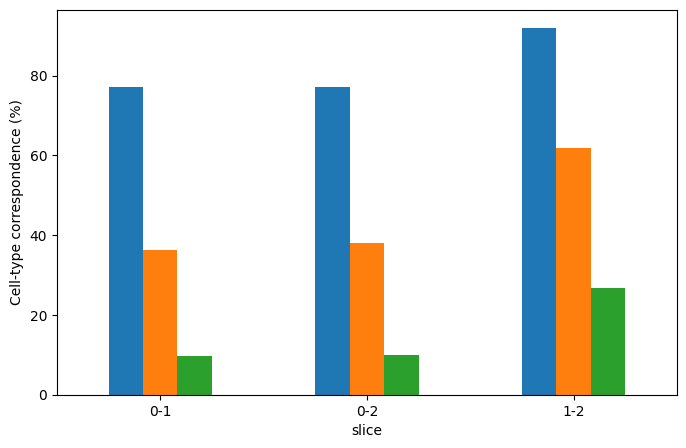

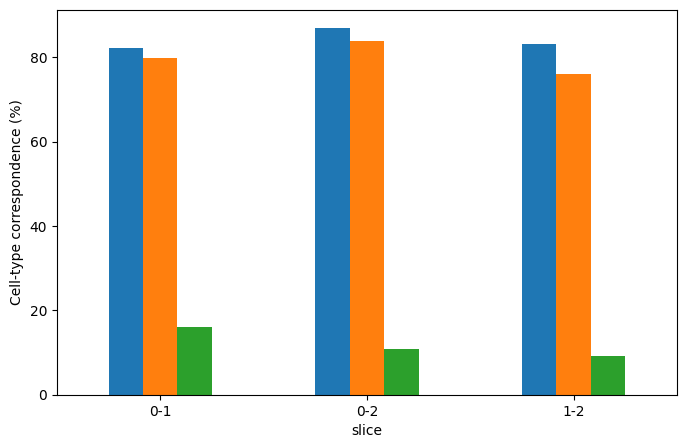

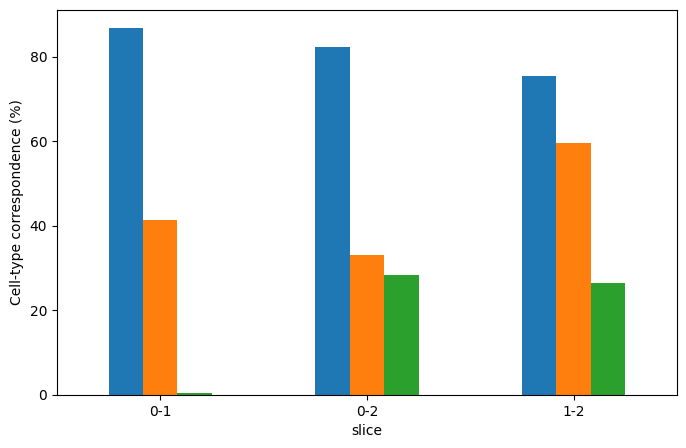

In [ ]:
plot_results()